**Tugas Clustering** \ actually this not pertemuan 8

**Nama : Ken Foster Morintoh**\
\
**NIM : 672020175**

Sebuah department store ingin menganalisa kelompok perilaku belanja dari pelanggannya, dengandata set yang diberikan buatlah analisa:\
a. Gunakan kolom ke 2 hingga 4 sebagai input features\
b. Dengan metode elbow, analisa jumlah cluster yang tepat\
c. Gunakan K-Means clustering dan analisa hasilnya

Sebuah department store ingin menganalisa kelompok perilaku belanja dari pelanggannya, dengandata set yang diberikan buatlah analisa:\
a. Gunakan kolom ke 2 hingga 4 sebagai input features\
b. Dengan metode elbow, analisa jumlah cluster yang tepat\
c. Gunakan K-Means clustering dan analisa hasilnya\
d. Bandingkan hasilnya dengan menggunakan metode K-Mean


**Kesimpulan:**



 Dari hasil analisis yang saya lakukan yaitu clustering dengan kmeans dan clustering dengan hierarikal adalah sebagai berikut :
 dari data dengan 3 fitur yang ada diatantaranya usia , rating, dan pendapatan.

**Clustering dengan K-means**

**cluster yang baik adalah 6 berdasarkan metode elbow pada k-mean**\
 -> Rating tertinggi (60 - 100) didapatkan pada constumer dengan rentang pendapatan 60-140 juta, denga usia 20-40 tahun (cluster biru)\
adapun Ratting tertinggi(60 - 100)  diberikan constumer yang umur 20 - 30 dengan pendapatan 0 - 40 juta (cluster hijau)\
-> Rating terendah 0 - 40 diberikan usia 0 - 70 dengan pendapatan 20 - 40 juta (cluster cyan dan kuning)\
-> Rating 40 - 60 diberikan customer pada usia 0-70 dengan pendapatan 40 - 60 (cluster merah dan cluster magenta)
pada cluster ini terbnyak dari dari keseluruhan data.



**Clustering dengan Hierarchy** 
walaupun dalam model ini kita bebas menetukan jumlah k-nya kita juga harus melihat struktur dendogram untuk mlihat berapa jumlah kluster yang optimal.\
disini saya tidak menarik gari potong dengan jarak euclidiannya >150.\
jadi , **jumlah cluster yang optimal adalah 6 cluster berdasarkan dendogram (garis potong <150)**



 -> Rating tertinggi (60 - 100) didapatkan pada constumer dengan rentang pendapatan 60-140 juta, denga usia 20-40 tahun (cluster biru) \
adapun Ratting tertinggi(60 - 100)  diberikan constumer yang umur 20 - 30 dengan pendapatan 0 - 40 juta (cluster hijau)\
-> Rating terendah 0 - 40 diberikan usia 0 - 70 dengan pendapatan 20 - 40 juta (cluster cyan dan kuning)\
-> Rating 40 - 60 diberikan customer pada usia 0-70 dengan pendapatan 40 - 60 (cluster merah dan cluster magenta)
pada cluster ini terbnyak dari dari keseluruhan data.

->Cluster 1 - 4 menunjukan adanya kemiripan(tergabung) pada jarak euclidian yang lebih besar.\

-> Begitupun cluster 5 dan 6 yang punya kemiripan(tergabung) dalam jarak euclidian yang lebih besar(lebih besar dibanding cluster 1- 4)

**perbandingan Kedua Model Clustering**
**dari analisis klustering dengan kedua model dibawah ini, keduanya memberikan hasil yang sangat mirip.**

Namun Perbedaan yang signifikan dari keduanya adalah di penyajian representasi visual dari struktur data dalam menentukan jumlah cluster. Pada hirarchy clustering kita mendapatkan dendogram struktur tree yang dapat menunjukan dimana jarak mereka digabungkan sendangkan K-mean tidak memberikan hubungan dari kesuluruhan data dimana jarak mereka tergabung.


In [1]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt


In [2]:
dataset = pd.read_csv('Customer.csv')

In [3]:
dataset

,IDPelanggan,Kelamin,Usia,Rating_belanja (1-100),Pendapatan (juta Rp)
0,1,Perempuan,23,87,29
1,2,Laki,60,4,30
2,3,Perempuan,21,73,30
3,4,Laki,53,4,33
4,5,Laki,18,92,33
...,...,...,...,...,...
195,196,Laki,28,75,87
196,197,Laki,36,10,87
197,198,Laki,36,92,87
198,199,Perempuan,52,13,88


In [4]:
dataset.describe()

,IDPelanggan,Usia,Rating_belanja (1-100),Pendapatan (juta Rp)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,50.200000,60.560000
std,57.879185,13.969007,25.823522,26.264721
min,1.000000,18.000000,1.000000,15.000000
25%,50.750000,28.750000,34.750000,41.500000
50%,100.500000,36.000000,50.000000,61.500000
75%,150.250000,49.000000,73.000000,78.000000
max,200.000000,70.000000,99.000000,137.000000


In [13]:
dataset['Kelamin'] = dataset.Kelamin.str.replace('Perempuan','0')
dataset['Kelamin'] = dataset.Kelamin.str.replace('Laki','1')


In [6]:
dataset.corr()

,IDPelanggan,Kelamin,Usia,Rating_belanja (1-100),Pendapatan (juta Rp)
IDPelanggan,1.000000,0.075370,-0.041300,0.011165,0.875266
Kelamin,0.075370,1.000000,0.060867,-0.058109,0.056410
Usia,-0.041300,0.060867,1.000000,-0.327227,-0.012398
Rating_belanja (1-100),0.011165,-0.058109,-0.327227,1.000000,0.009903
Pendapatan (juta Rp),0.875266,0.056410,-0.012398,0.009903,1.000000


In [8]:
dataset.isnull().sum()

IDPelanggan               0
Kelamin                   0
Usia                      0
Rating_belanja (1-100)    0
Pendapatan (juta Rp)      0
dtype: int64

In [14]:
dataset.dtypes

IDPelanggan                int64
Kelamin                   object
Usia                       int64
Rating_belanja (1-100)     int64
Pendapatan (juta Rp)       int64
dtype: object

In [21]:
dataset_noid= dataset.drop(columns=['IDPelanggan', 'Kelamin'])

dataset_noid



,Usia,Rating_belanja (1-100),Pendapatan (juta Rp)
0,23,87,29
1,60,4,30
2,21,73,30
3,53,4,33
4,18,92,33
...,...,...,...
195,28,75,87
196,36,10,87
197,36,92,87
198,52,13,88


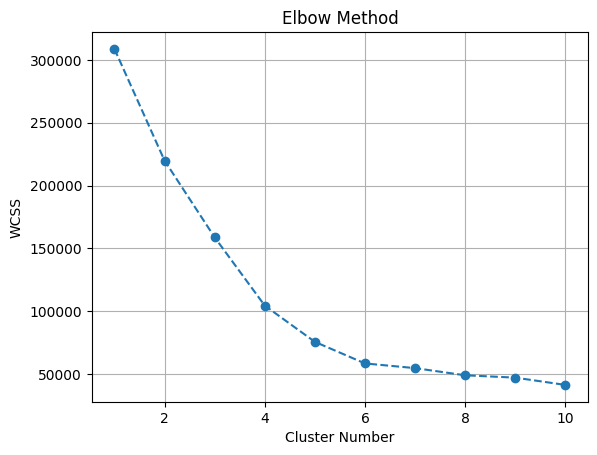

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans

# Mengimpor dataset
dataset = pd.read_csv('Customer.csv')
X = dataset.iloc[:, [2,3,4]].values

# Optimasi K-Means dengan metode elbow untuk menentukan jumlah klaster yang
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    
plt.plot(range(1, 11), wcss, marker='o', linestyle = '--')
plt.title('Elbow Method')
plt.xlabel('Cluster Number')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

Reatif tidak mudah menentukan jumlah optimal K dsini saya memilih 6 sebagai k-optimal berdasarkan plot yang ada menggunakan k-means\
namun Kerena plotnya masih melambai kurang merepresenstasikan siku(elbow). \




**untuk memastikan membuktikan 6 adalah cluster yang tepat saya melakukan analisis silhoutee**

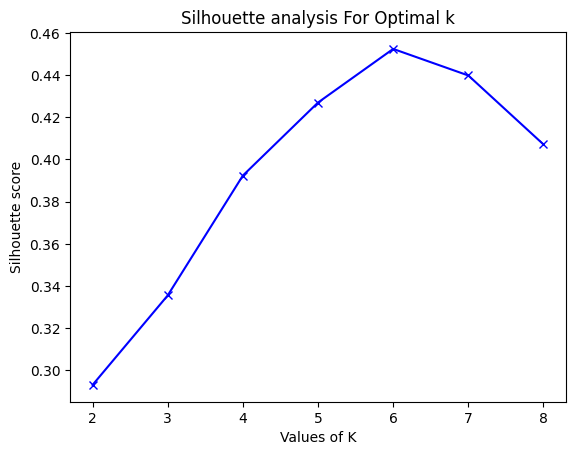

In [22]:
#analisis silhoutte untuk menemukan jumlah k yang optimal
from sklearn.metrics import silhouette_score
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
silhouette_avg = []
for num_clusters in range_n_clusters:
 
 # K-means
 kmeans = KMeans(n_clusters=num_clusters)
 kmeans.fit(dataset_noid)
 cluster_labels = kmeans.labels_
 
 # silhouette score
 silhouette_avg.append(silhouette_score(dataset_noid, cluster_labels))
plt.plot(range_n_clusters,silhouette_avg,'bx-')
plt.xlabel('Values of K') 
plt.ylabel('Silhouette score') 
plt.title('Silhouette analysis For Optimal k')
plt.show()

For n_clusters = 2 The average silhouette_score is : 0.3319705845155097
For n_clusters = 3 The average silhouette_score is : 0.31066851393354694
For n_clusters = 4 The average silhouette_score is : 0.3896462456432733
For n_clusters = 5 The average silhouette_score is : 0.37806530024103246
For n_clusters = 6 The average silhouette_score is : 0.4523566166018854


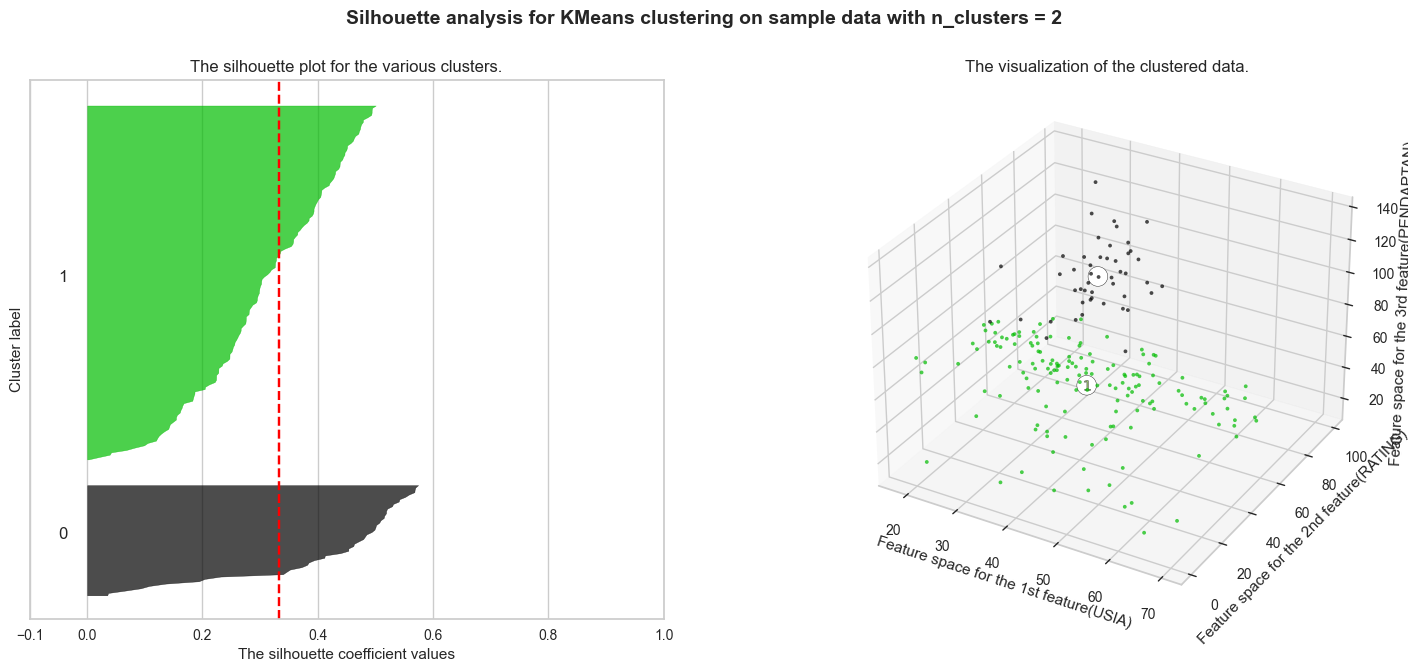

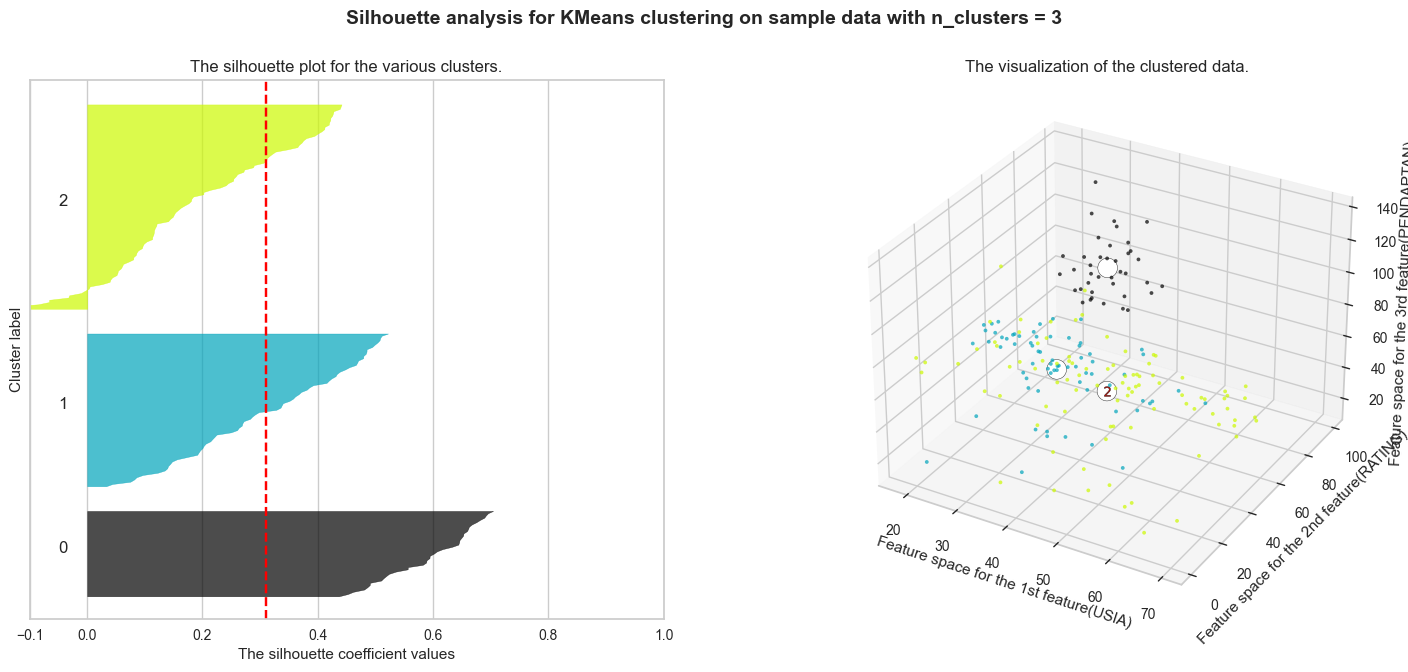

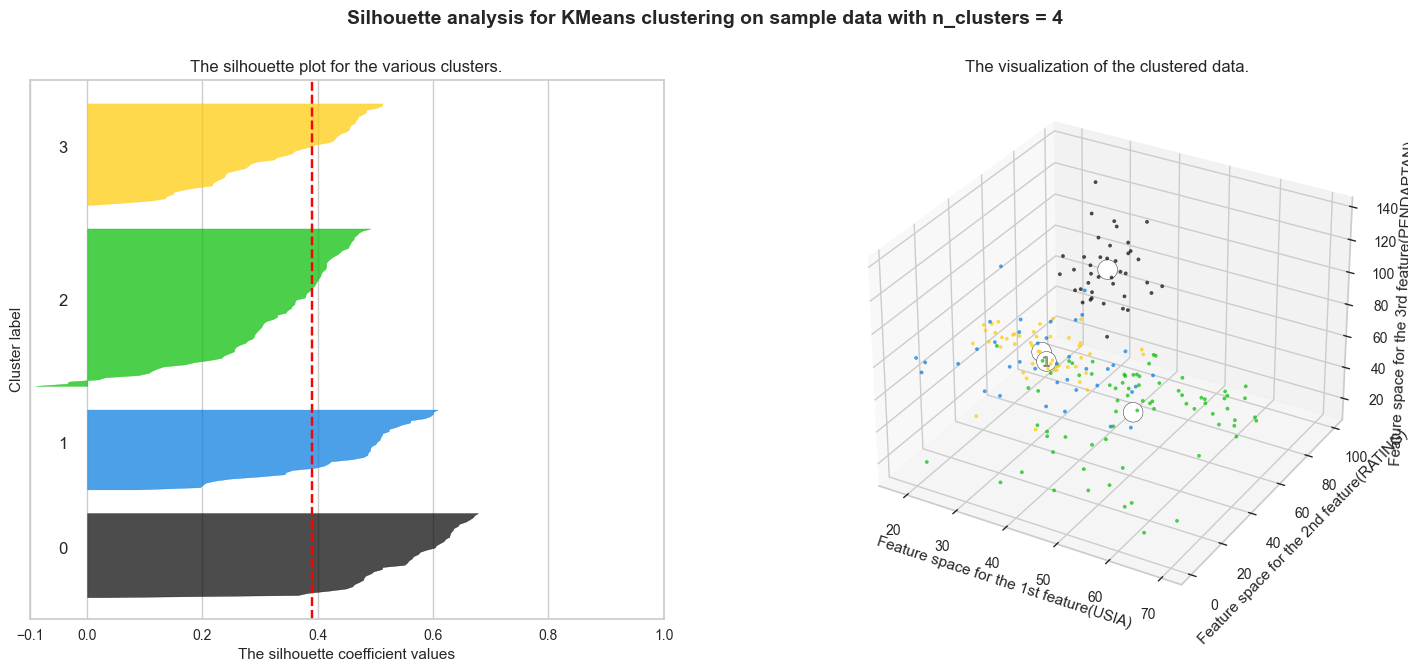

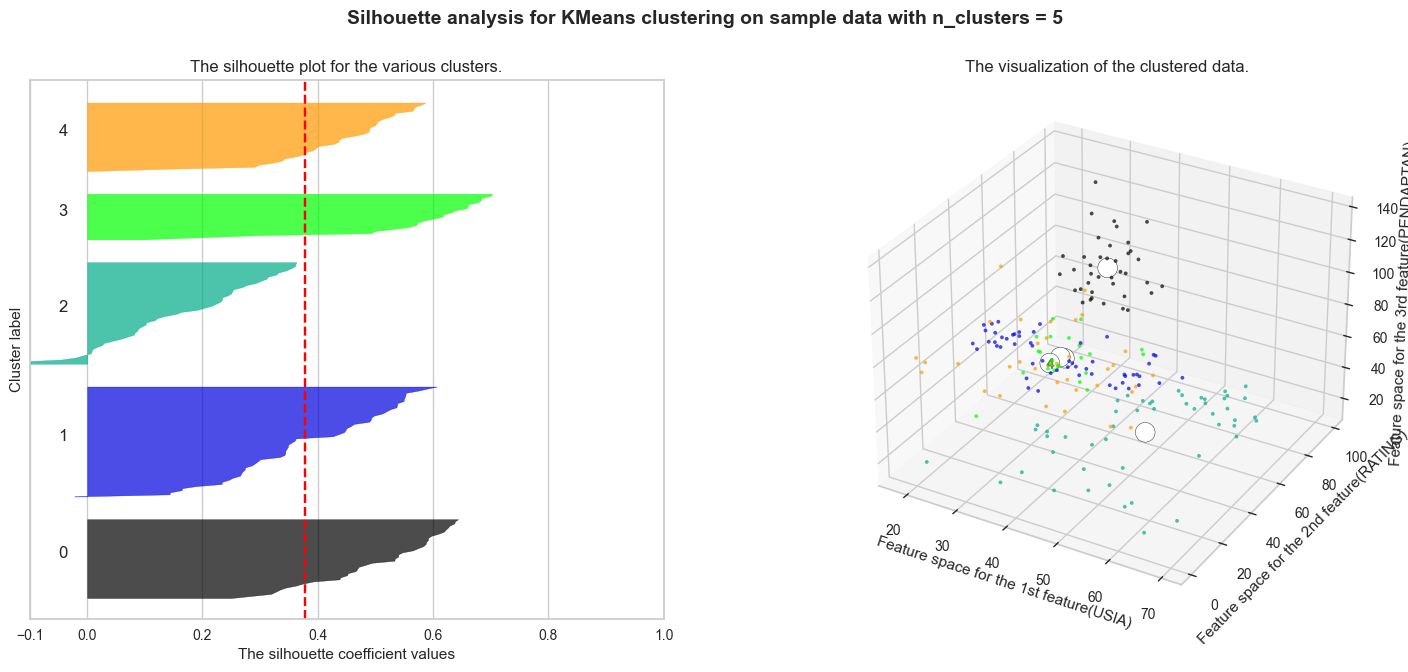

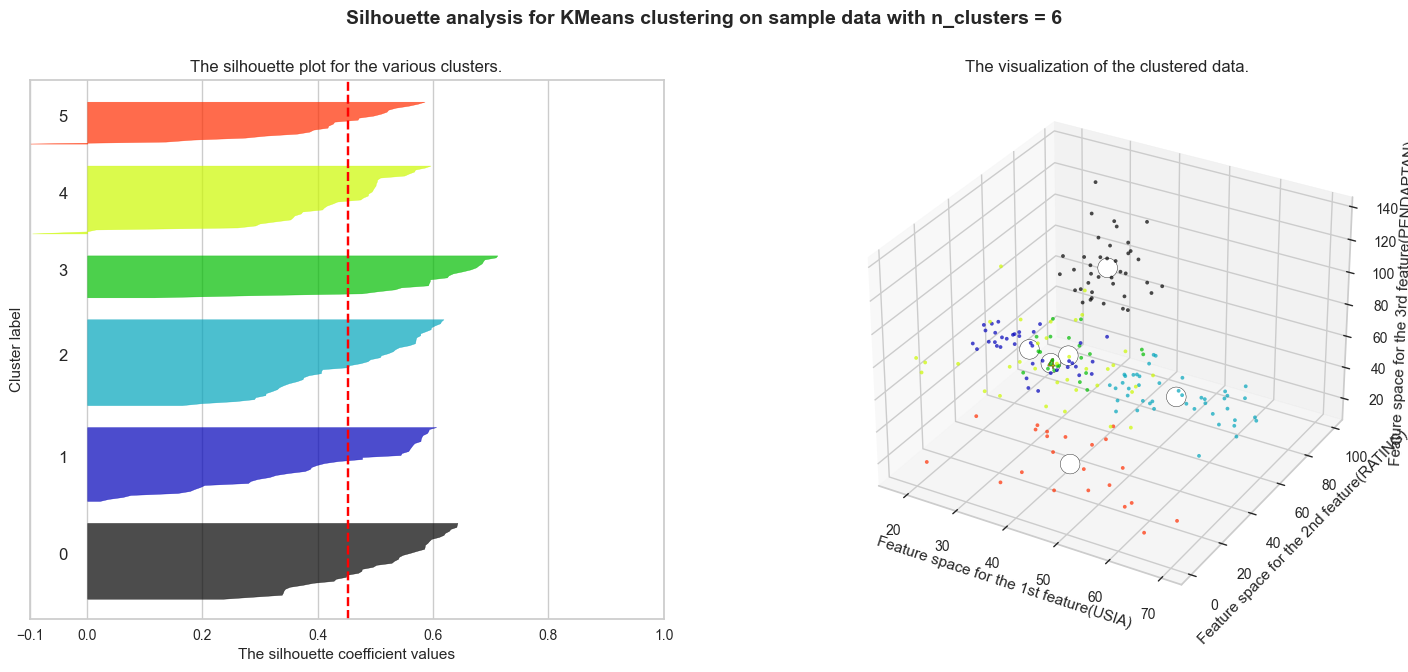

In [27]:
import pandas as pd
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

# Load your datase

range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig = plt.figure(figsize=(18, 7))
    ax1 = fig.add_subplot(121)
    ax2 = fig.add_subplot(122, projection='3d')

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X[:, 0], X[:, 1], X[:, 2], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        centers[:, 2],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], c[2], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature(USIA)")
    ax2.set_ylabel("Feature space for the 2nd feature(RATING)")
    ax2.set_zlabel("Feature space for the 3rd feature(PENDAPTAN)")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()


In [26]:
X.shape

(200, 3)

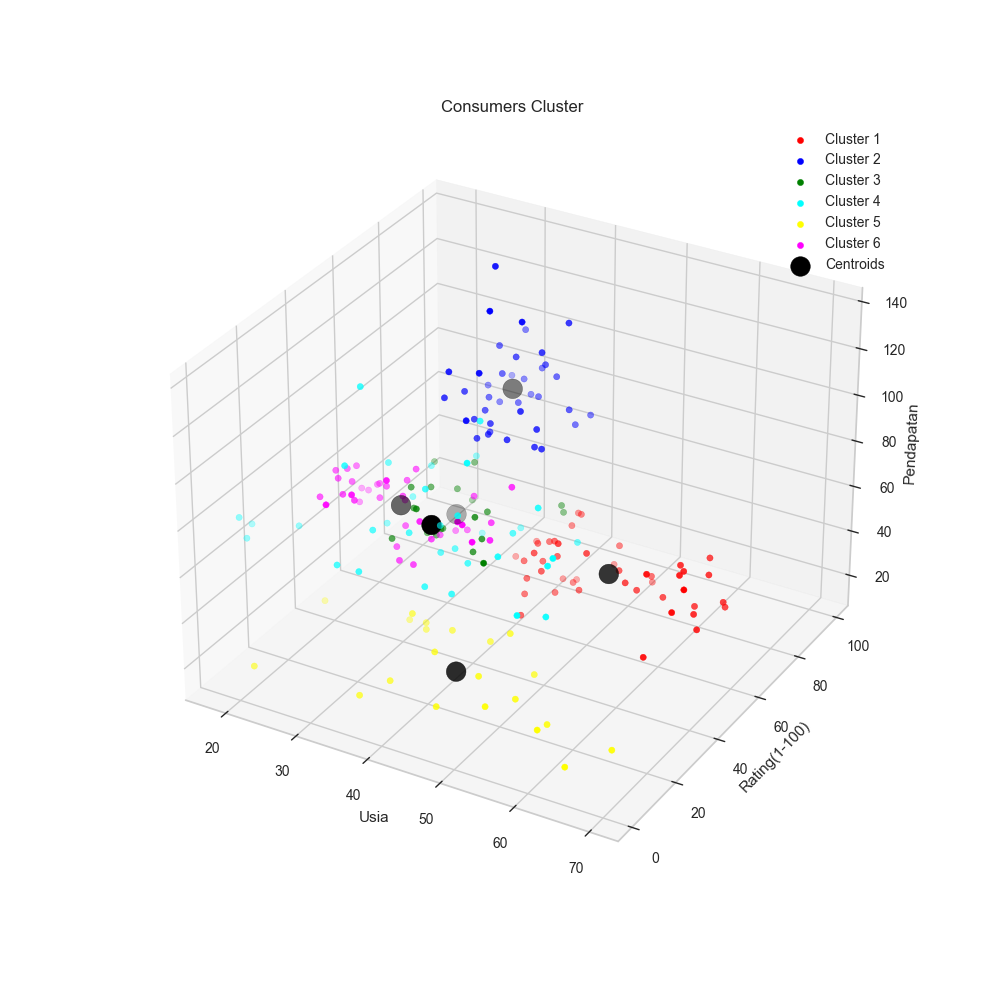

In [29]:
from mpl_toolkits.mplot3d import Axes3D


%matplotlib widget 
# Proses K-Means Clustering
kmeans = KMeans(n_clusters=6, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)


fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
# Visualisasi hasil clusters

ax.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1],  X[y_kmeans == 0,2],c = 'red', label = 'Cluster 1')
ax.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], X[y_kmeans == 1,2],c = 'blue', label = 'Cluster 2')
ax.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], X[y_kmeans == 2,2],c = 'green', label = 'Cluster 3')
ax.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], X[y_kmeans == 3,2] ,c = 'cyan', label = 'Cluster 4')
ax.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], X[y_kmeans == 4,2] ,c = 'yellow', label = 'Cluster 5')
ax.scatter(X[y_kmeans == 5, 0], X[y_kmeans == 5, 1], X[y_kmeans == 5,2] ,c = 'magenta', label = 'Cluster 6')

#plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='black', label='Centroids')
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2], s=200, c='black', label='Centroids')
ax.set_title('Consumers Cluster')
ax.set_xlabel('Usia')
ax.set_ylabel('Rating(1-100)')
ax.set_zlabel('Pendapatan')
ax.legend()

plt.show()

**1. Rating tertinggi (60 - 100) didapatkan pada constumer dengan rentang pendapatan 60-140 juta, denga usia 20-40 tahun (cluster biru) \
adapun Ratting tertinggi(60 - 100)  didpatkan  didapakan berdasarkan umur 20 - 30 dengan pendapatan 0 - 40 juta (cluster hijau)\
2. Rating terendah 0 - 40 pada usia 0 - 70 dengan pendapatan 20 - 40 juta (cluster cyan dan kuning)\
3. Rating 40 - 60 diperoleh pada usia 0-70 dengan pendapatan 40 - 60 (cluster merah dan cluster magenta)**

**Berikutnya adalah Clustering dengan Hierarky**

disini saya menggunakan algomertive (cluster bottom to up)





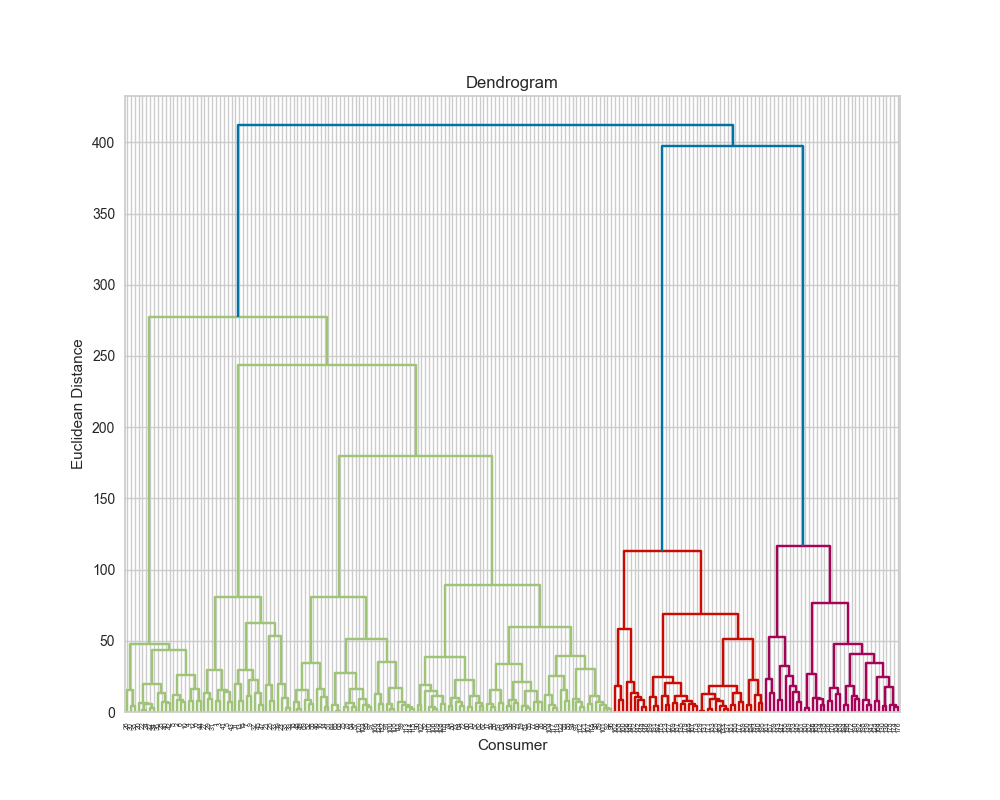

In [33]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(10, 8))
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))

plt.title('Dendrogram')
plt.xlabel('Consumer')
plt.ylabel('Euclidean Distance', rotation = 90)
plt.show()

Berdasarkan dendoogram diatas cukup jelas bahwa cluster yang baik dipilih adalah 6. 

saya mengambil garis potong (jarak euclidian) dari <150 
cluster 1, 2, 3, dan 4 (hijau) dimana cenderung punya kemiripan.
Cluster 5 dan cluster 6 punya kemripan. 

In [34]:
from sklearn.cluster import AgglomerativeClustering

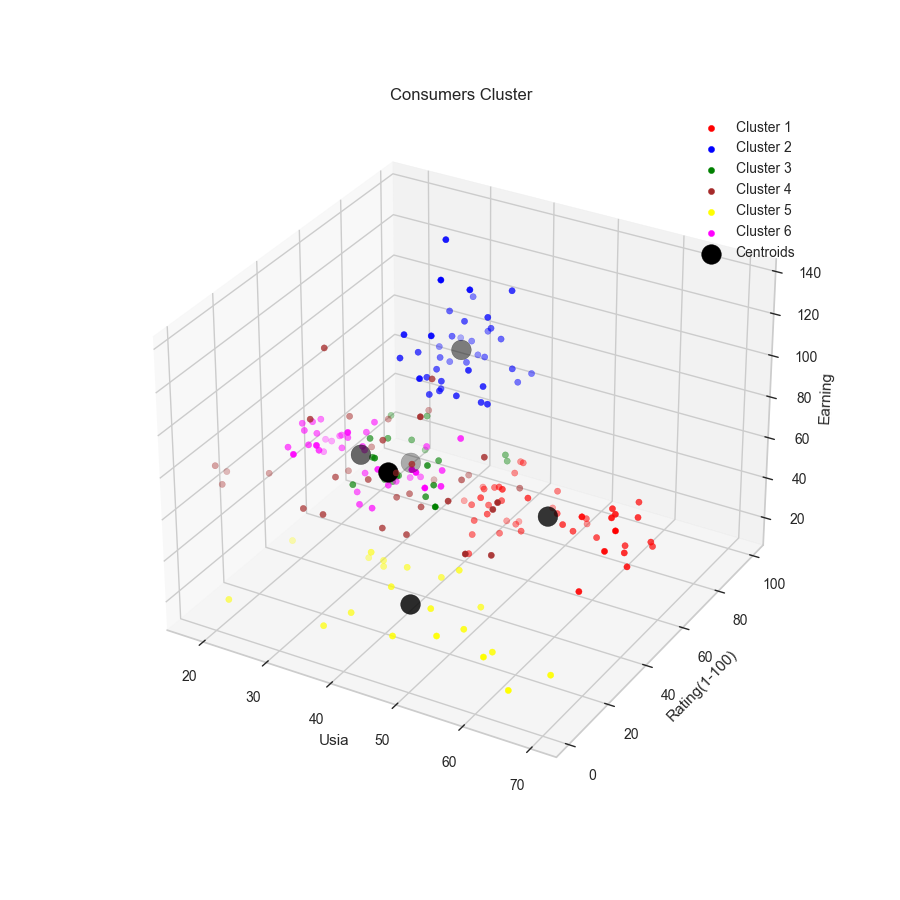

In [37]:
# Menjalankan Hierarchical Clustering ke dataset

from mpl_toolkits.mplot3d import Axes3D

hc = AgglomerativeClustering(n_clusters=6, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X)


fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection='3d')

# Visualisasi hasil clusters
ax.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1],  X[y_kmeans == 0,2],c = 'red', label = 'Cluster 1')
ax.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], X[y_kmeans == 1,2],c = 'blue', label = 'Cluster 2')
ax.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], X[y_kmeans == 2,2],c = 'green', label = 'Cluster 3')
ax.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], X[y_kmeans == 3,2] ,c = 'brown', label = 'Cluster 4')
ax.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], X[y_kmeans == 4,2] ,c = 'yellow', label = 'Cluster 5')
ax.scatter(X[y_kmeans == 5, 0], X[y_kmeans == 5, 1], X[y_kmeans == 5,2] ,c = 'magenta', label = 'Cluster 6')

#plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='black', label='Centroids')
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2], s=200, c='black', label='Centroids')
ax.set_title('Consumers Cluster')
ax.set_xlabel('Usia')
ax.set_ylabel('Rating(1-100)')
ax.set_zlabel('Earning')
ax.legend()

# Plotting the centroids of the clusters (using first two features)

# plt.title('Consumers Cluster')
# plt.xlabel('Custumers')
# plt.ylabel('Salary')
# plt.legend()
plt.show()